# Calculadora de Testes de Hipótese (Paramétricos)

Este notebook permite realizar testes de hipótese para médias, variâncias e proporções, tanto para uma quanto para duas populações.

### Como usar:
1. Execute a célula de **Setup**.
2. Execute a célula de **Funções de Teste** (mecanismo central).
3. Escolha o tipo de teste desejado nas seções abaixo, altere os parâmetros e execute (Shift+Enter).

## ⚙️ Setup

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('default')
    
print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 🛠️ Funções de Teste
Execute esta célula uma única vez para carregar todos os mecanismos de cálculo e visualização.

In [ ]:
def plot_teste_hipotese(dist, estatistica, val_crit, tipo_teste, alfa, nome_teste):
    """Gera o gráfico da distribuição com as regiões de rejeição."""
    plt.figure(figsize=(10, 5))
    
    # Obter nome da distribuição de forma robusta (frozen ou não)
    d_name = getattr(dist, 'name', getattr(getattr(dist, 'dist', {}), 'name', ''))
    
    # Definir range de x
    if d_name == 'norm' or d_name == 't':
        x = np.linspace(-4, 4, 1000)
    elif d_name == 'chi2':
        x = np.linspace(0, dist.ppf(0.999), 1000)
    elif d_name == 'f':
        x = np.linspace(0, dist.ppf(0.999), 1000)
    
    y = dist.pdf(x)
    plt.plot(x, y, 'k-', lw=2, label='Distribuição sob H₀')
    
    # Colorir regiões de rejeição
    if tipo_teste == 'duas_caudas':
        crit_inf, crit_sup = val_crit
        x_left = np.linspace(x.min(), crit_inf, 100)
        x_right = np.linspace(crit_sup, x.max(), 100)
        plt.fill_between(x_left, dist.pdf(x_left), color='red', alpha=0.3, label='Região de Rejeição')
        plt.fill_between(x_right, dist.pdf(x_right), color='red', alpha=0.3)
    elif tipo_teste == 'cauda_esquerda':
        x_fill = np.linspace(x.min(), val_crit, 100)
        plt.fill_between(x_fill, dist.pdf(x_fill), color='red', alpha=0.3, label='Região de Rejeição')
    elif tipo_teste == 'cauda_direita':
        x_fill = np.linspace(val_crit, x.max(), 100)
        plt.fill_between(x_fill, dist.pdf(x_fill), color='red', alpha=0.3, label='Região de Rejeição')

    # Marcar a estatística observada
    plt.axvline(estatistica, color='blue', linestyle='--', lw=2, label=f'Estatística Observada: {estatistica:.4f}')
    
    plt.title(f"Visualização: {nome_teste}")
    plt.legend()
    plt.show()

def exibir_resultados(teste_nome, res, dist):
    """Função auxiliar para imprimir os resultados e gerar gráficos."""
    print(f"\n--- Resultados do {teste_nome} ---")
    print(f"Estatística de Teste: {res['estatistica_teste']:.4f}")
    print(f"P-valor (Valor de Prova): {res['p_valor']:.4f}")

    val_crit = res['valor_critico']
    if isinstance(val_crit, tuple):
        print(f"Valor Crítico (α={res['alfa']}, {res['tipo_teste']}): Inferior = {val_crit[0]:.4f}, Superior = {val_crit[1]:.4f}")
    else:
        print(f"Valor Crítico (α={res['alfa']}, {res['tipo_teste']}): {val_crit:.4f}")

    if 'graus_de_liberdade' in res: print(f"Graus de Liberdade: {res['graus_de_liberdade']:.2f}")
    if 'graus_de_liberdade_numerador' in res:
        print(f"GL (Numerador): {res['graus_de_liberdade_numerador']} | GL (Denominador): {res['graus_de_liberdade_denominador']}")
    
    status = "REJEITADA" if res['hipotese_rejeitada'] else "NÃO REJEITADA"
    print(f"\n👉 Conclusão: A hipótese nula (H₀) é {status}.")
    
    if res.get('power') is not None:
        print(f"\n--- Análise de Potência ---")
        print(f"Potência (1 - β): {res['power']:.4f}")
        print(f"β (Prob. Erro Tipo II): {1 - res['power']:.4f}")

    # Gerar Gráfico
    plot_teste_hipotese(dist, res['estatistica_teste'], val_crit, res['tipo_teste'], res['alfa'], teste_nome)

def teste_qui_quadrado_variancia_uma_amostra(variancia_amostral, tamanho_amostra, variancia_pop_hipotetica, tipo_teste='duas_caudas', alfa=0.05, variancia_pop_alternativa=None):
    n, s2, sigma02 = tamanho_amostra, variancia_amostral, variancia_pop_hipotetica
    estatistica = (n - 1) * s2 / sigma02; df = n - 1
    dist = st.chi2(df)
    if tipo_teste == 'duas_caudas':
        p_val = 2 * min(dist.sf(estatistica), dist.cdf(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    power = None
    if variancia_pop_alternativa:
        nc = (n - 1) * (variancia_pop_alternativa / sigma02)
        if tipo_teste == 'duas_caudas': power = st.ncx2.cdf(val_crit[0], df, nc) + st.ncx2.sf(val_crit[1], df, nc)
        elif tipo_teste == 'cauda_esquerda': power = st.ncx2.cdf(val_crit, df, nc)
        else: power = st.ncx2.sf(val_crit, df, nc)

    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'graus_de_liberdade': df, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste Qui-Quadrado (Variância/1 amostra)", res, dist)

def teste_f_variancia_duas_amostras(var1, n1, var2, n2, tipo_teste='duas_caudas', alfa=0.05, ratio_alternativo=None):
    estatistica = var1 / var2; dfn, dfd = n1 - 1, n2 - 1
    dist = st.f(dfn, dfd)
    if tipo_teste == 'duas_caudas':
        p_val = 2 * min(dist.sf(estatistica), dist.cdf(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    power = None
    if ratio_alternativo:
        if tipo_teste == 'duas_caudas': power = st.ncf.cdf(val_crit[0], dfn, dfd, ratio_alternativo) + st.ncf.sf(val_crit[1], dfn, dfd, ratio_alternativo)
        elif tipo_teste == 'cauda_esquerda': power = st.ncf.cdf(val_crit, dfn, dfd, ratio_alternativo)
        else: power = st.ncf.sf(val_crit, dfn, dfd, ratio_alternativo)

    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'graus_de_liberdade_numerador': dfn, 'graus_de_liberdade_denominador': dfd, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste F (Diferença de Variâncias)", res, dist)

def teste_z_media_uma_amostra(media_amostral, n, mu0, sigma_pop, tipo_teste='duas_caudas', alfa=0.05, mu_H1=None):
    estatistica = (media_amostral - mu0) / (sigma_pop / np.sqrt(n))
    dist = st.norm()
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    power = None
    if mu_H1 is not None:
        shift = (mu_H1 - mu0) / (sigma_pop / np.sqrt(n))
        dist_h1 = st.norm(loc=shift)
        if tipo_teste == 'duas_caudas': power = dist_h1.cdf(val_crit[0]) + dist_h1.sf(val_crit[1])
        elif tipo_teste == 'cauda_esquerda': power = dist_h1.cdf(val_crit)
        else: power = dist_h1.sf(val_crit)

    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste Z (Média/1 amostra - σ conhecido)", res, dist)

def teste_t_media_uma_amostra(media_amostral, n, mu0, s_amostral, tipo_teste='duas_caudas', alfa=0.05, mu_H1=None):
    estatistica = (media_amostral - mu0) / (s_amostral / np.sqrt(n)); df = n - 1
    dist = st.t(df)
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    power = None
    if mu_H1 is not None:
        nc = (mu_H1 - mu0) / (s_amostral / np.sqrt(n))
        if tipo_teste == 'duas_caudas': power = st.nct.cdf(val_crit[0], df, nc) + st.nct.sf(val_crit[1], df, nc)
        elif tipo_teste == 'cauda_esquerda': power = st.nct.cdf(val_crit, df, nc)
        else: power = st.nct.sf(val_crit, df, nc)

    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'graus_de_liberdade': df, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste t (Média/1 amostra - σ desconhecido)", res, dist)

def teste_z_media_duas_amostras(media1, n1, sigma1, media2, n2, sigma2, dif0=0, tipo_teste='duas_caudas', alfa=0.05, dif_H1=None):
    erro_padrao = np.sqrt(sigma1**2/n1 + sigma2**2/n2)
    estatistica = (media1 - media2 - dif0) / erro_padrao
    dist = st.norm()
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)

    power = None
    if dif_H1 is not None:
        shift = (dif_H1 - dif0) / erro_padrao
        dist_h1 = st.norm(loc=shift)
        if tipo_teste == 'duas_caudas': power = dist_h1.cdf(val_crit[0]) + dist_h1.sf(val_crit[1])
        elif tipo_teste == 'cauda_esquerda': power = dist_h1.cdf(val_crit)
        else: power = dist_h1.sf(val_crit)
        
    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste Z (Comparação de Médias - σ conhecidos)", res, dist)

def teste_t_media_duas_amostras(media1, n1, s1, media2, n2, s2, dif0=0, var_iguais=False, tipo_teste='duas_caudas', alfa=0.05, dif_H1=None):
    if var_iguais:
        sp2 = ((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2); sp = np.sqrt(sp2)
        erro_padrao = sp * np.sqrt(1/n1 + 1/n2); df = n1 + n2 - 2
    else:
        erro_padrao = np.sqrt(s1**2/n1 + s2**2/n2)
        gl_num = (s1**2/n1 + s2**2/n2)**2
        gl_den = (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)
        df = gl_num / gl_den
    
    dist = st.t(df)
    estatistica = (media1 - media2 - dif0) / erro_padrao
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    power = None
    if dif_H1 is not None:
        nc = (dif_H1 - dif0) / erro_padrao
        if tipo_teste == 'duas_caudas': power = st.nct.cdf(val_crit[0], df, nc) + st.nct.sf(val_crit[1], df, nc)
        elif tipo_teste == 'cauda_esquerda': power = st.nct.cdf(val_crit, df, nc)
        else: power = st.nct.sf(val_crit, df, nc)
        
    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'graus_de_liberdade': df, 'valor_critico': val_crit, 'power': power}
    exibir_resultados("Teste t (Welch ou agrupado - Comparação de Médias)", res, dist)

def teste_t_pareado(media_dif, n, s_dif, mu_d0=0, tipo_teste='duas_caudas', alfa=0.05, mu_d_H1=None):
    estatistica = (media_dif - mu_d0) / (s_dif / np.sqrt(n)); df = n - 1
    dist = st.t(df)
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'graus_de_liberdade': df, 'valor_critico': val_crit}
    exibir_resultados("Teste t Pareado (Diferença de Médias)", res, dist)

def teste_z_proporcao_uma_amostra(p_amostral, n, p0, tipo_teste='duas_caudas', alfa=0.05):
    estatistica = (p_amostral - p0) / np.sqrt(p0*(1-p0)/n)
    dist = st.norm()
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'valor_critico': val_crit}
    exibir_resultados("Teste Z (Proporção/1 amostra)", res, dist)

def teste_z_proporcao_duas_amostras(p1, n1, p2, n2, dif0=0, tipo_teste='duas_caudas', alfa=0.05):
    p_pool = (p1*n1 + p2*n2) / (n1+n2)
    erro_padrao = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    dist = st.norm()
    estatistica = (p1 - p2 - dif0) / erro_padrao
    if tipo_teste == 'duas_caudas':
        p_val = 2 * dist.sf(abs(estatistica))
        val_crit = (dist.ppf(alfa/2), dist.ppf(1 - alfa/2))
    elif tipo_teste == 'cauda_esquerda':
        p_val = dist.cdf(estatistica); val_crit = dist.ppf(alfa)
    else: # cauda_direita
        p_val = dist.sf(estatistica); val_crit = dist.ppf(1 - alfa)
    
    res = {'estatistica_teste': estatistica, 'p_valor': p_val, 'hipotese_rejeitada': p_val < alfa, 'alfa': alfa, 'tipo_teste': tipo_teste, 'valor_critico': val_crit}
    exibir_resultados("Teste Z (Comparação de Proporções)", res, dist)

## 1️⃣ Testes para UM Parâmetro
Use estas células quando quiser testar se a Média, Variância ou Proporção de uma população é igual a um valor hipotético.

### 1.a) Média (Teste t ou Z)


--- Resultados do Teste t (Média/1 amostra - σ desconhecido) ---
Estatística de Teste: 2.0833
P-valor (Valor de Prova): 0.0480
Valor Crítico (α=0.05, duas_caudas): Inferior = -2.0639, Superior = 2.0639
Graus de Liberdade: 24.00

👉 Conclusão: A hipótese nula (H₀) é REJEITADA.

--- Análise de Potência ---
Potência (1 - β): 0.9791
β (Prob. Erro Tipo II): 0.0209


/Users/gbuenos/Projetos Local/feup/estatística/feup-est-repo/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


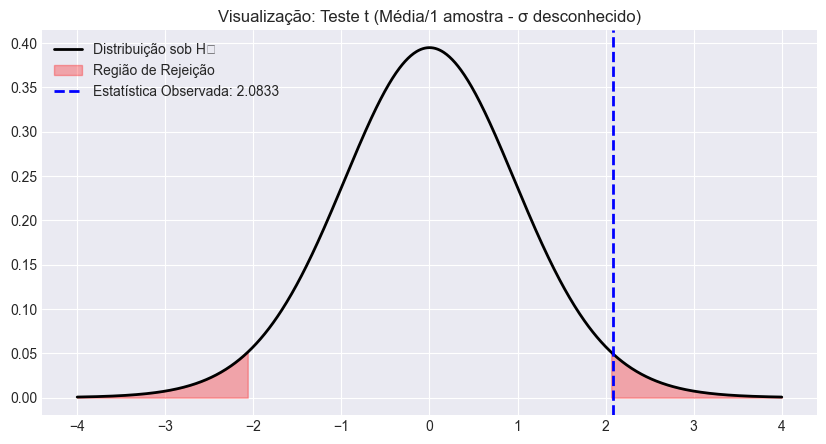

In [38]:
# Escolha Z (σ conhecido) ou t (σ desconhecido)
teste_t_media_uma_amostra(
    media_amostral = 10.5,      # Média observada na amostra (x̄)
    n = 25,                     # Tamanho da amostra (número de observações)
    mu0 = 10.0,                 # Média populacional sob a hipótese nula (H₀: μ = μ₀)
    s_amostral = 1.2,           # Desvio padrão da amostra (s) - σ é desconhecido
    tipo_teste = 'duas_caudas', # Tipo de teste: 'duas_caudas' (≠), 'cauda_esquerda' (<), 'cauda_direita' (>)
    alfa = 0.05,                # Nível de significância (α) - probabilidade de erro Tipo I
    mu_H1 = 11.0                # Valor alternativo da média (μ₁) para cálculo de Poder do Teste (1-β)
)



--- Resultados do Teste Z (Média/1 amostra - σ conhecido) ---
Estatística de Teste: 2.5000
P-valor (Valor de Prova): 0.0124
Valor Crítico (α=0.05, duas_caudas): Inferior = -1.9600, Superior = 1.9600

👉 Conclusão: A hipótese nula (H₀) é REJEITADA.

--- Análise de Potência ---
Potência (1 - β): 0.9988
β (Prob. Erro Tipo II): 0.0012


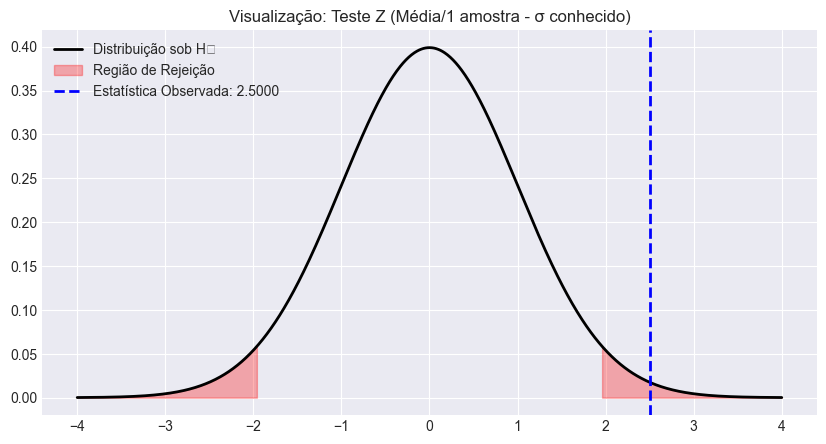

In [39]:
# Caso conheça o σ populacional
teste_z_media_uma_amostra(
    media_amostral = 10.5,      # Média observada na amostra (x̄)
    n = 25,                     # Tamanho da amostra (número de observações)
    mu0 = 10.0,                 # Média populacional sob a hipótese nula (H₀: μ = μ₀)
    sigma_pop = 1.0,            # Desvio padrão populacional (σ) - CONHECIDO
    tipo_teste = 'duas_caudas', # Tipo de teste: 'duas_caudas' (≠), 'cauda_esquerda' (<), 'cauda_direita' (>)
    alfa = 0.05,                # Nível de significância (α)
    mu_H1 = 11.0                # Valor alternativo da média (μ₁) para Poder do Teste
)


### 1.b) Variância (Qui-Quadrado)


--- Resultados do Teste Qui-Quadrado (Variância/1 amostra) ---
Estatística de Teste: 15.2000
P-valor (Valor de Prova): 0.5804
Valor Crítico (α=0.05, duas_caudas): Inferior = 8.9065, Superior = 32.8523
Graus de Liberdade: 19.00

👉 Conclusão: A hipótese nula (H₀) é NÃO REJEITADA.

--- Análise de Potência ---
Potência (1 - β): 0.2852
β (Prob. Erro Tipo II): 0.7148


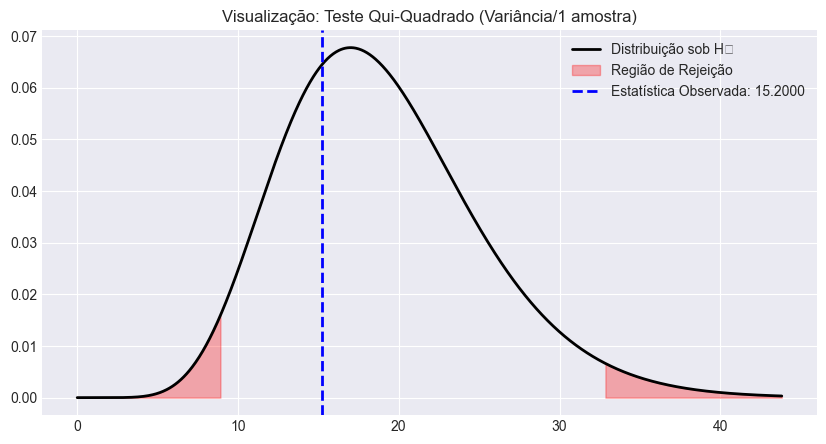

In [40]:
teste_qui_quadrado_variancia_uma_amostra(
    variancia_amostral = 1.44,   # Variância da amostra (s²)
    tamanho_amostra = 25,        # n (número de observações)
    variancia_pop_hipotetica = 1.0, # Variância sob H₀ (σ₀²)
    tipo_teste = 'cauda_direita', # 'duas_caudas', 'cauda_esquerda', 'cauda_direita'
    alfa = 0.05,                 # Nível de significância (α)
    variancia_pop_alternativa = 1.2 # σ₁² para cálculo de Poder do Teste (opcional)
)


### 1.c) Proporção (Teste Z)


--- Resultados do Teste Z (Proporção/1 amostra) ---
Estatística de Teste: 2.0000
P-valor (Valor de Prova): 0.0455
Valor Crítico (α=0.05, duas_caudas): Inferior = -1.9600, Superior = 1.9600

👉 Conclusão: A hipótese nula (H₀) é REJEITADA.


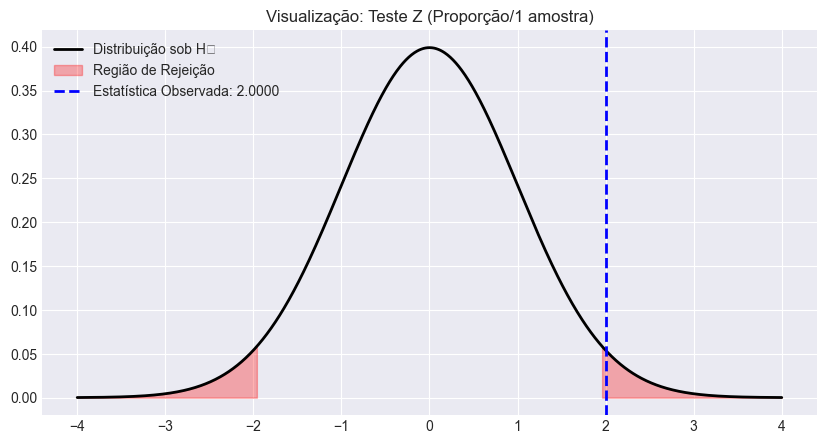

In [41]:
teste_z_proporcao_uma_amostra(
    p_amostral = 0.65,          # Proporção observada na amostra (p̂)
    n = 100,                    # Tamanho da amostra
    p0 = 0.5,                   # Proporção hipotética sob H₀ (p₀)
    tipo_teste = 'duas_caudas', # Tipo de teste
    alfa = 0.05                 # Nível de significância (α)
)


## 2️⃣ Testes para DOIS Parâmetros (Comparação)
Use estas células para comparar duas populações.

### 2.a) Comparação de Médias (Amostras Independentes)


--- Resultados do Teste t (Welch ou agrupado - Comparação de Médias) ---
Estatística de Teste: 2.9314
P-valor (Valor de Prova): 0.0047
Valor Crítico (α=0.05, duas_caudas): Inferior = -1.9984, Superior = 1.9984
Graus de Liberdade: 62.96

👉 Conclusão: A hipótese nula (H₀) é REJEITADA.

--- Análise de Potência ---
Potência (1 - β): 0.2253
β (Prob. Erro Tipo II): 0.7747


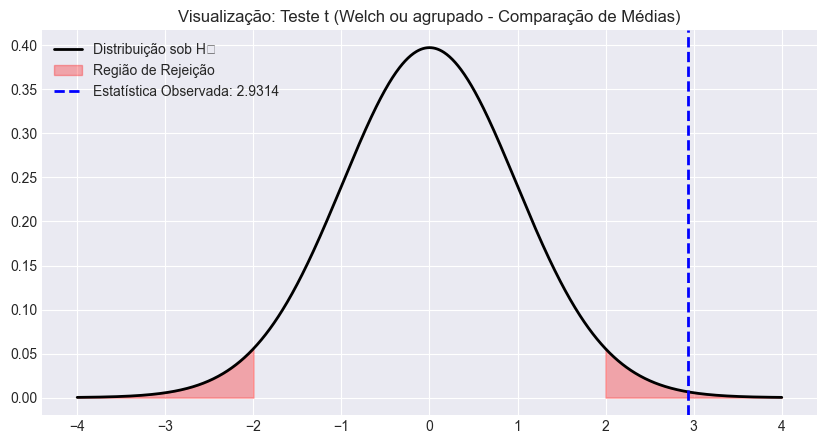

In [42]:
teste_t_media_duas_amostras(
    media1 = 12.4, n1 = 30, s1 = 1.5,   # média, n e DP da Amostra 1
    media2 = 11.2, n2 = 35, s2 = 1.8,   # média, n e DP da Amostra 2
    dif0 = 0,                           # Δ₀ (diferença hipotética μ1 - μ2, geralm. 0)
    var_iguais = False,                 # True: Variâncias Iguais | False: Welch (Varia. Dif.)
    tipo_teste = 'duas_caudas',         # 'duas_caudas', 'cauda_esquerda', 'cauda_direita'
    alfa = 0.05,                        # α
    dif_H1 = 0.5                        # Δ₁ (diferença real sob H1 para potência)
)

### 2.b) Comparação de Variâncias (Teste F)


--- Resultados do Teste F (Diferença de Variâncias) ---
Estatística de Teste: 1.5556
P-valor (Valor de Prova): 0.2666
Valor Crítico (α=0.05, duas_caudas): Inferior = 0.4472, Superior = 2.1946
GL (Numerador): 24 | GL (Denominador): 27

👉 Conclusão: A hipótese nula (H₀) é NÃO REJEITADA.

--- Análise de Potência ---
Potência (1 - β): 0.0526
β (Prob. Erro Tipo II): 0.9474


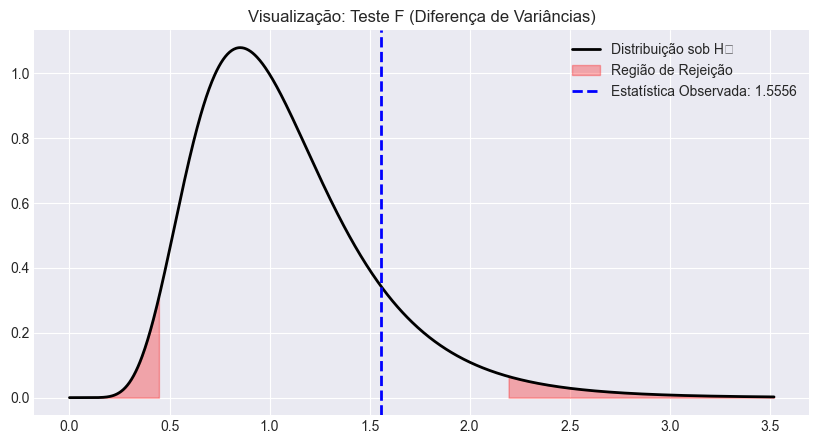

In [43]:
teste_f_variancia_duas_amostras(
    var1 = 1.5,                 # Variância da Amostra 1 (s₁²)
    n1 = 20,                    # Tamanho da Amostra 1
    var2 = 1.0,                 # Variância da Amostra 2 (s₂²)
    n2 = 25,                    # Tamanho da Amostra 2
    tipo_teste = 'duas_caudas', # Tipo de teste para H₀: σ₁²/σ₂² = 1
    alfa = 0.05,                # Nível de significância (α)
    ratio_alternativo = 1.25    # Razão alternativa (σ₁²/σ₂²) para Poder do Teste
)


### 2.c) Comparação de Proporções (Teste Z)


--- Resultados do Teste Z (Comparação de Proporções) ---
Estatística de Teste: 1.4996
P-valor (Valor de Prova): 0.1337
Valor Crítico (α=0.05, duas_caudas): Inferior = -1.9600, Superior = 1.9600

👉 Conclusão: A hipótese nula (H₀) é NÃO REJEITADA.


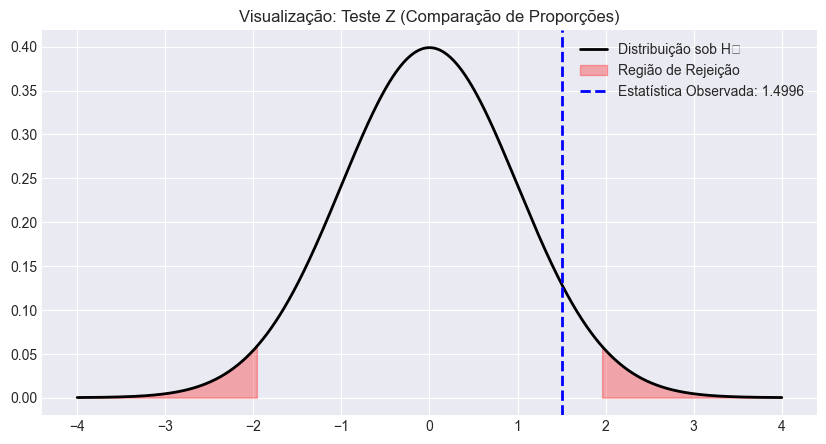

In [44]:
teste_z_proporcao_duas_amostras(
    p1 = 0.60,                  # Proporção observada na Amostra 1 (p̂₁)
    n1 = 120,                   # Tamanho da Amostra 1
    p2 = 0.50,                  # Proporção observada na Amostra 2 (p̂₂)
    n2 = 150,                   # Tamanho da Amostra 2
    dif0 = 0,                   # Diferença hipotética sob H₀ (p₁ - p₂ = 0)
    tipo_teste = 'duas_caudas', # Tipo de teste
    alfa = 0.05                 # Nível de significância (α)
)


### 2.d) Médias Pareadas (Amostras Dependentes)


--- Resultados do Teste t Pareado (Diferença de Médias) ---
Estatística de Teste: 9.2952
P-valor (Valor de Prova): 0.0000
Valor Crítico (α=0.05, duas_caudas): Inferior = -2.1448, Superior = 2.1448
Graus de Liberdade: 14.00

👉 Conclusão: A hipótese nula (H₀) é REJEITADA.


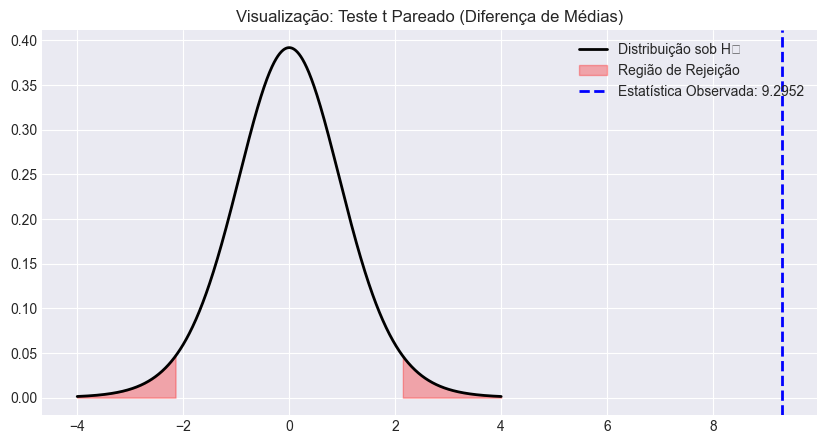

In [45]:
teste_t_pareado(
    media_dif = 2.5,            # Média das diferenças observadas (d̄)
    n = 15,                     # Número de pares (tamanho da amostra)
    s_dif = 1.8,                # Desvio padrão das diferenças (s_d)
    mu_d0 = 0,                  # Valor de referência sob H₀ (geralmente 0)
    tipo_teste = 'cauda_direita', # 'duas_caudas', 'cauda_esquerda', 'cauda_direita'
    alfa = 0.05                 # Nível de significância (α)
)
